In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using EccentricBurstTiming, CairoMakie, QuadGK, CSV
using JLD2
# using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming
const DATADIR = joinpath(@__DIR__, "..", "data")

  Activating project at `~/projects/EccentricBurstTimings`


"/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data"

In [2]:
G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1
c_solar = 0.4309220324852666 # R⊙/s

function get_unperturbed_model(;args...)
    args = copy(args)

    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)
    
    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

function decay_time_s(a0, e0, m1, m2)
    G³ = G_solar^3
    c⁵ = c_solar^5

    β = 64/5*(G³*m1*m2*(m1 + m2))/c⁵
    c0 = a0*(1 - e0^2)/(e0^(12/19))*(1 + 121/304*e0^2)^(-870/2299)
    integral(e) = (e^(29/19)*(1 + (121/304)*e^2)^(1181/2299))/sqrt(1 - e^2)^3

    int, err = quadgk(integral, 0, e0)

    T = 12/19*c0^4/β*int
    return T
end

function orbital_period_s(a, m1, m2)
    return 2π*sqrt(a^3/(G_solar*(m1 + m2)))
end

orbital_period_s (generic function with 1 method)

In [3]:
function get_kummer_models(filename="GW_advanced_high_density_Z0005.csv"; e_min=0.1, Z="0005")
    filepath = joinpath(DATADIR, "kummer2024", "data_models", "Z$Z", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        # !iszero(i%2) && continue
        !parse(Bool, lowercase(row.gw)) && continue
        iszero(parse(Float64, row.time)) && continue
        parse(Bool, lowercase(row.merger)) && continue
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.incl)
        
        R3 = parse(Float64, row.a_out)
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

function get_bruenech_models(filename="triple-induced-mergers.csv"; e_min=0.1)
    filepath = joinpath(DATADIR, "triple_bhbs", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.i_mut)
        
        R3 = parse(Float64, row.a_out)
        R3 < zero(R3) && continue
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

get_bruenech_models (generic function with 2 methods)

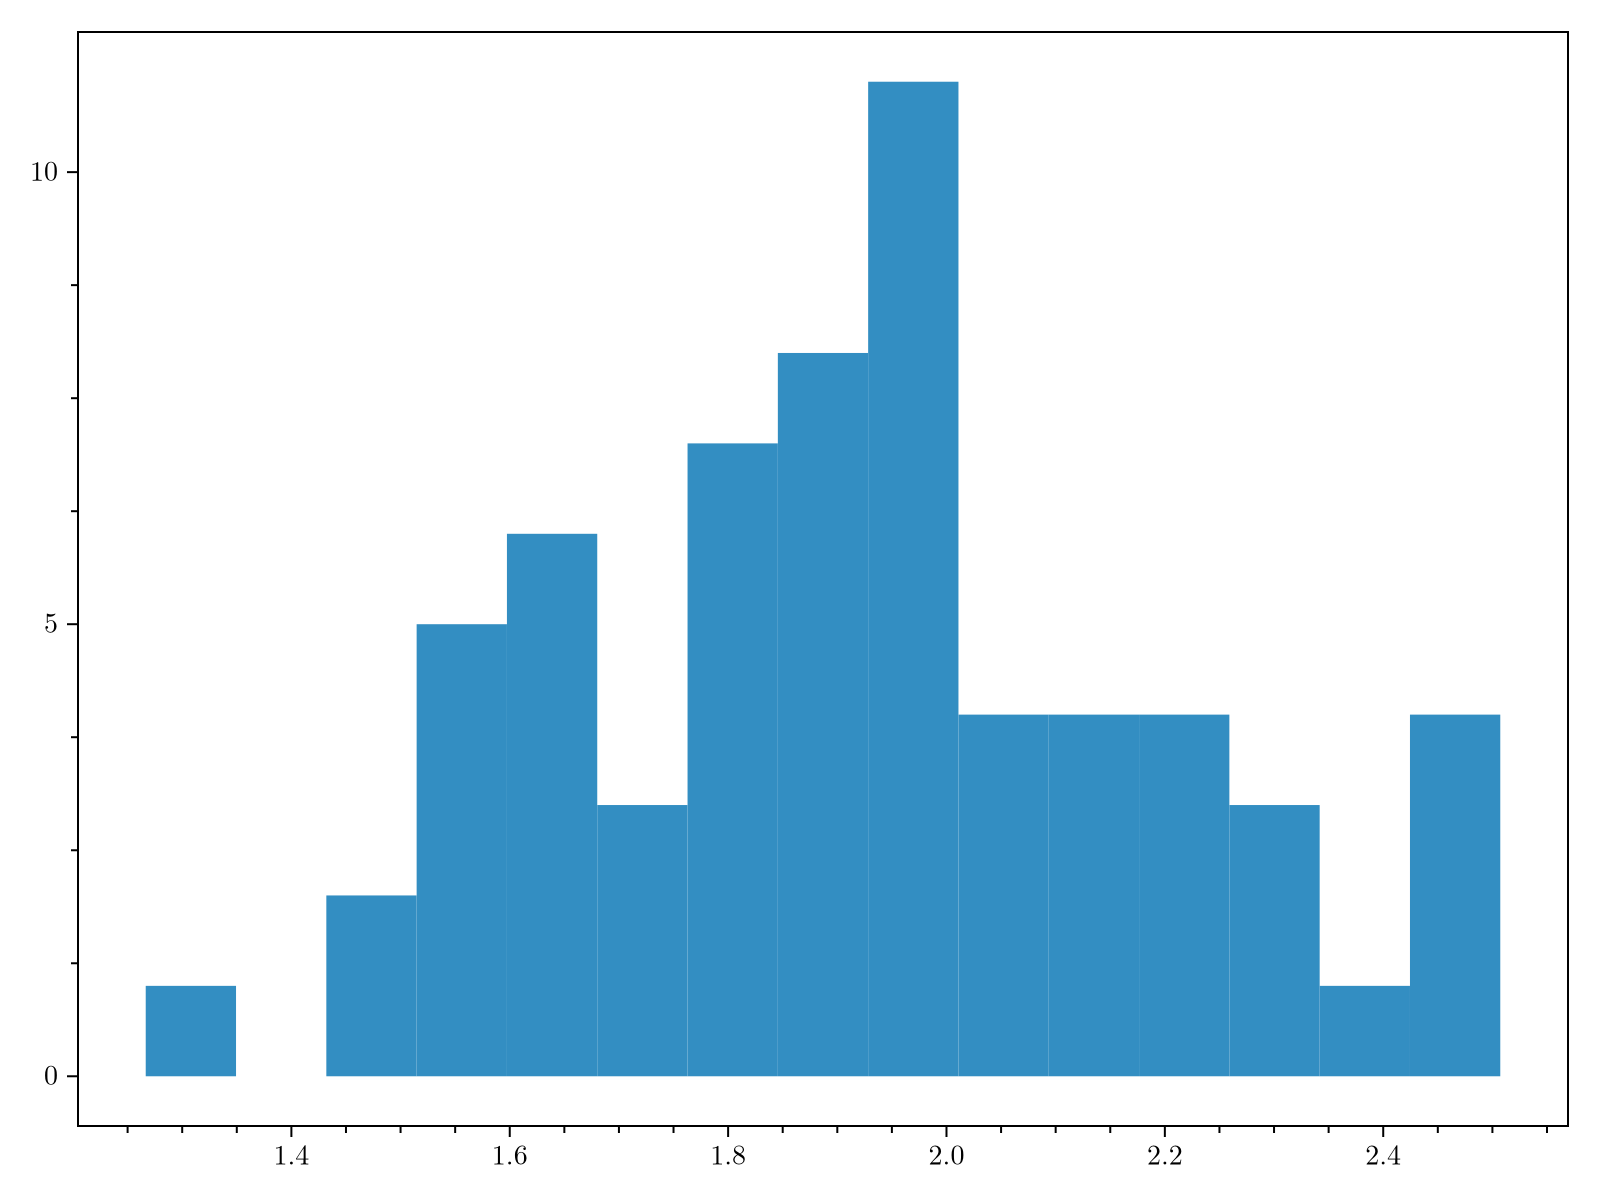

In [6]:
let models = get_kummer_models("GW_advanced_high_density_Z0005.csv", e_min=0.7)
    alpha = Float64[]
    for (id, p) in models
        push!(alpha, p[:R3]/p[:a0])
    end

    hist(log10.(alpha))
end

87.67022246059523


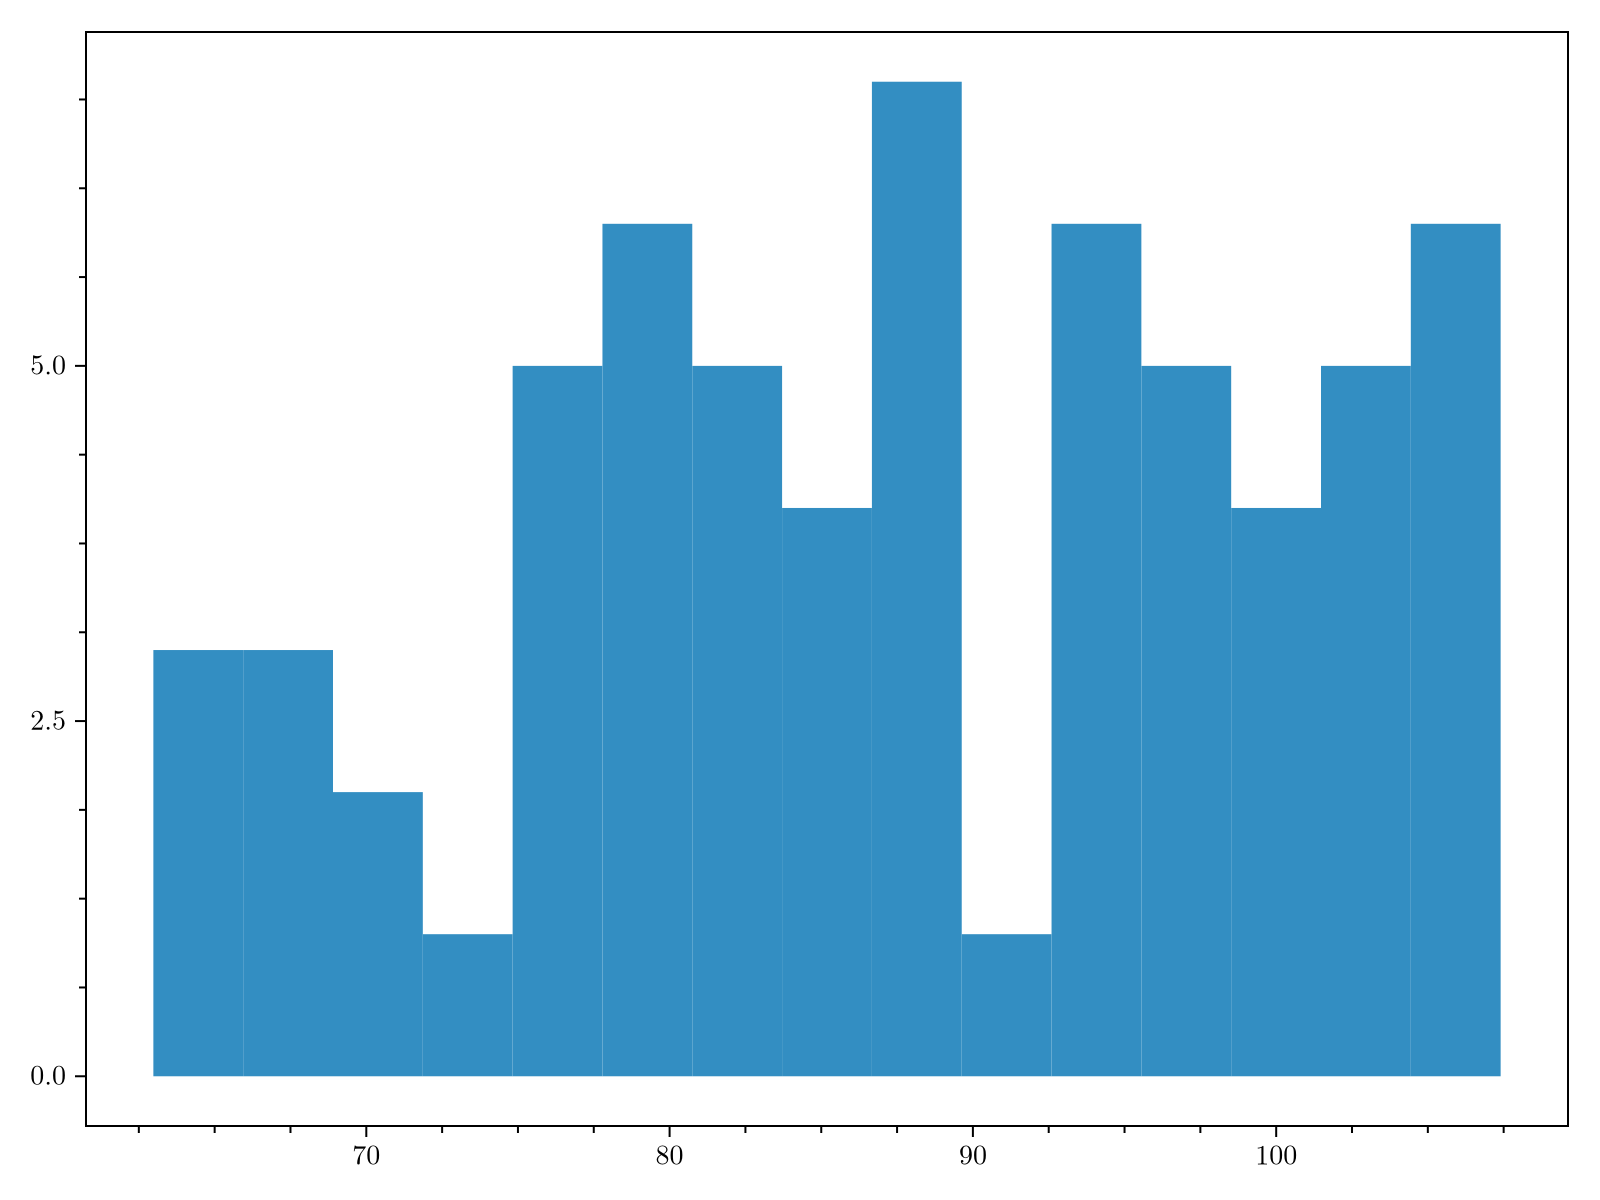

In [6]:
let models = get_kummer_models("GW_advanced_high_density_Z0005.csv", e_min=0.7)
    m3s = Float64[]
    for (id, p) in models
        push!(m3s, p[:m1]+p[:m2])
    end

    println(sum(m3s)/length(m3s))
    hist(m3s)
end

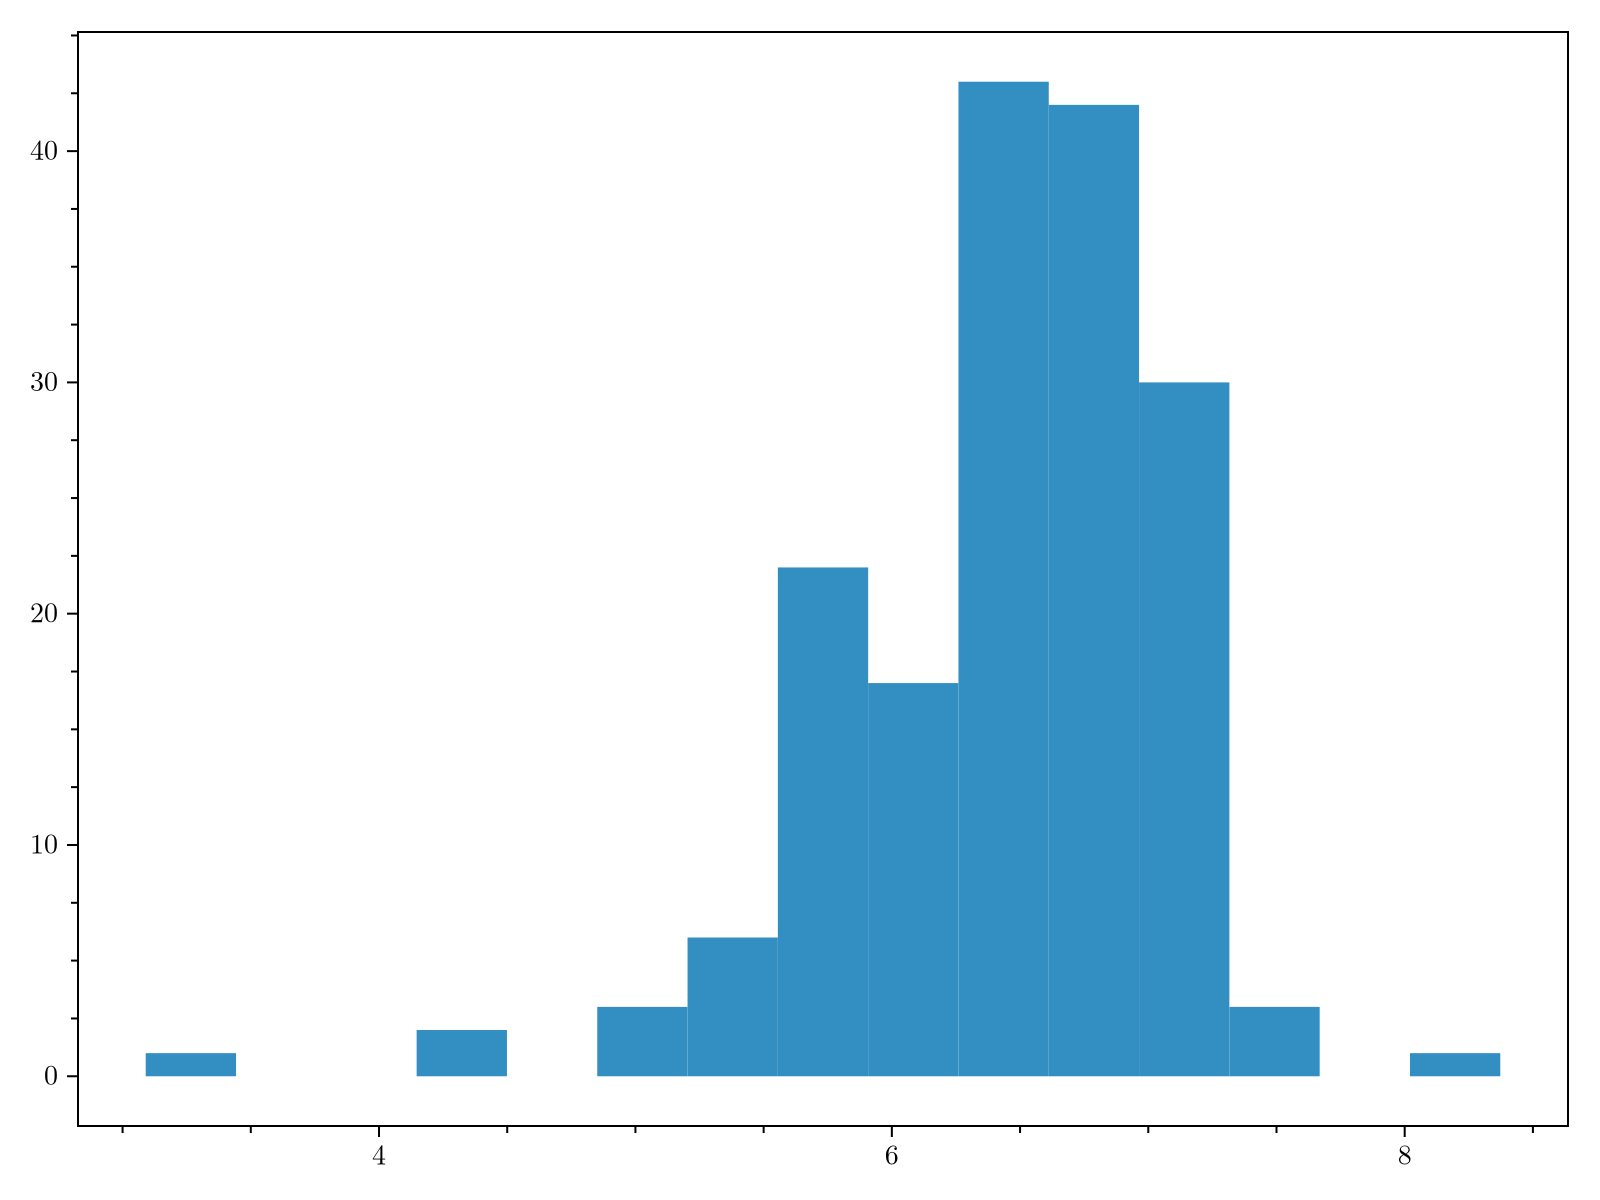

In [8]:
let models = get_bruenech_models()
    alpha = Float64[]
    for (id, p) in models
        push!(alpha, p[:R3]/p[:a0])
    end

    hist(log10.(alpha))
end

## Example

In [169]:
let models = get_kummer_models("simple_high_density_Z0005.csv", e_min=0.7)
    
    # IDs = sort(collect(keys(models)))
    # println(IDs[1])
    params = models[1891]

    # params = models[5572]
    # params[:R3] = params[:R3]
    # params[:V3] = π

    m_up, m_p = get_models(;params...)

    # return EBT.get_R(m), EBT.get_Rmin(m, m.η₃/m.η)
    # return EBT.get_Rmin(m, m.η₃/m.η)/(m.p₃/(1 - m.e₃))
    return EBT.peak_f_GW(m_up, 1)
    evolve!(m_p, 20_000_000, f_GW_max=100, e_min=0.0001, verbose=true, Rmin_threshold=Inf, do_outer_orbit=true, save_every=20)
    evolve!(m_up, 50_000_000, f_GW_max=100, e_min=0.0001, verbose=true, Rmin_threshold=Inf, save_every=100)
    
    N = length(m_up.t)
    println(length(m_p.t))
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    linkxaxes!(ax, ax_e, ax_i)

    let m = m_up
        t = get_t_array(m, N)
        t = t .- t[end]
        a = get_a_array(m, N) ./ EBT.Rsun_to_m
        e = get_e_array(m, N)
        i = EBT.get_i_array(m, N)

        lines!(ax, t, a)
        lines!(ax_e, t, 1 .- e)
        lines!(ax_i, t, i)
    end

    let m = m_p
        t = get_t_array(m, N)
        t = t .- t[end]
        a = get_a_array(m, N) ./ EBT.Rsun_to_m
        e = get_e_array(m, N)
        i = EBT.get_i_array(m, N)

        lines!(ax, t, a, linestyle=:dash)
        lines!(ax_e, t, 1 .- e, linestyle=:dash)
        lines!(ax_i, t, i, linestyle=:dash)
    end

    fig
end

0.00509266067850842

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:217
┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:217


956681


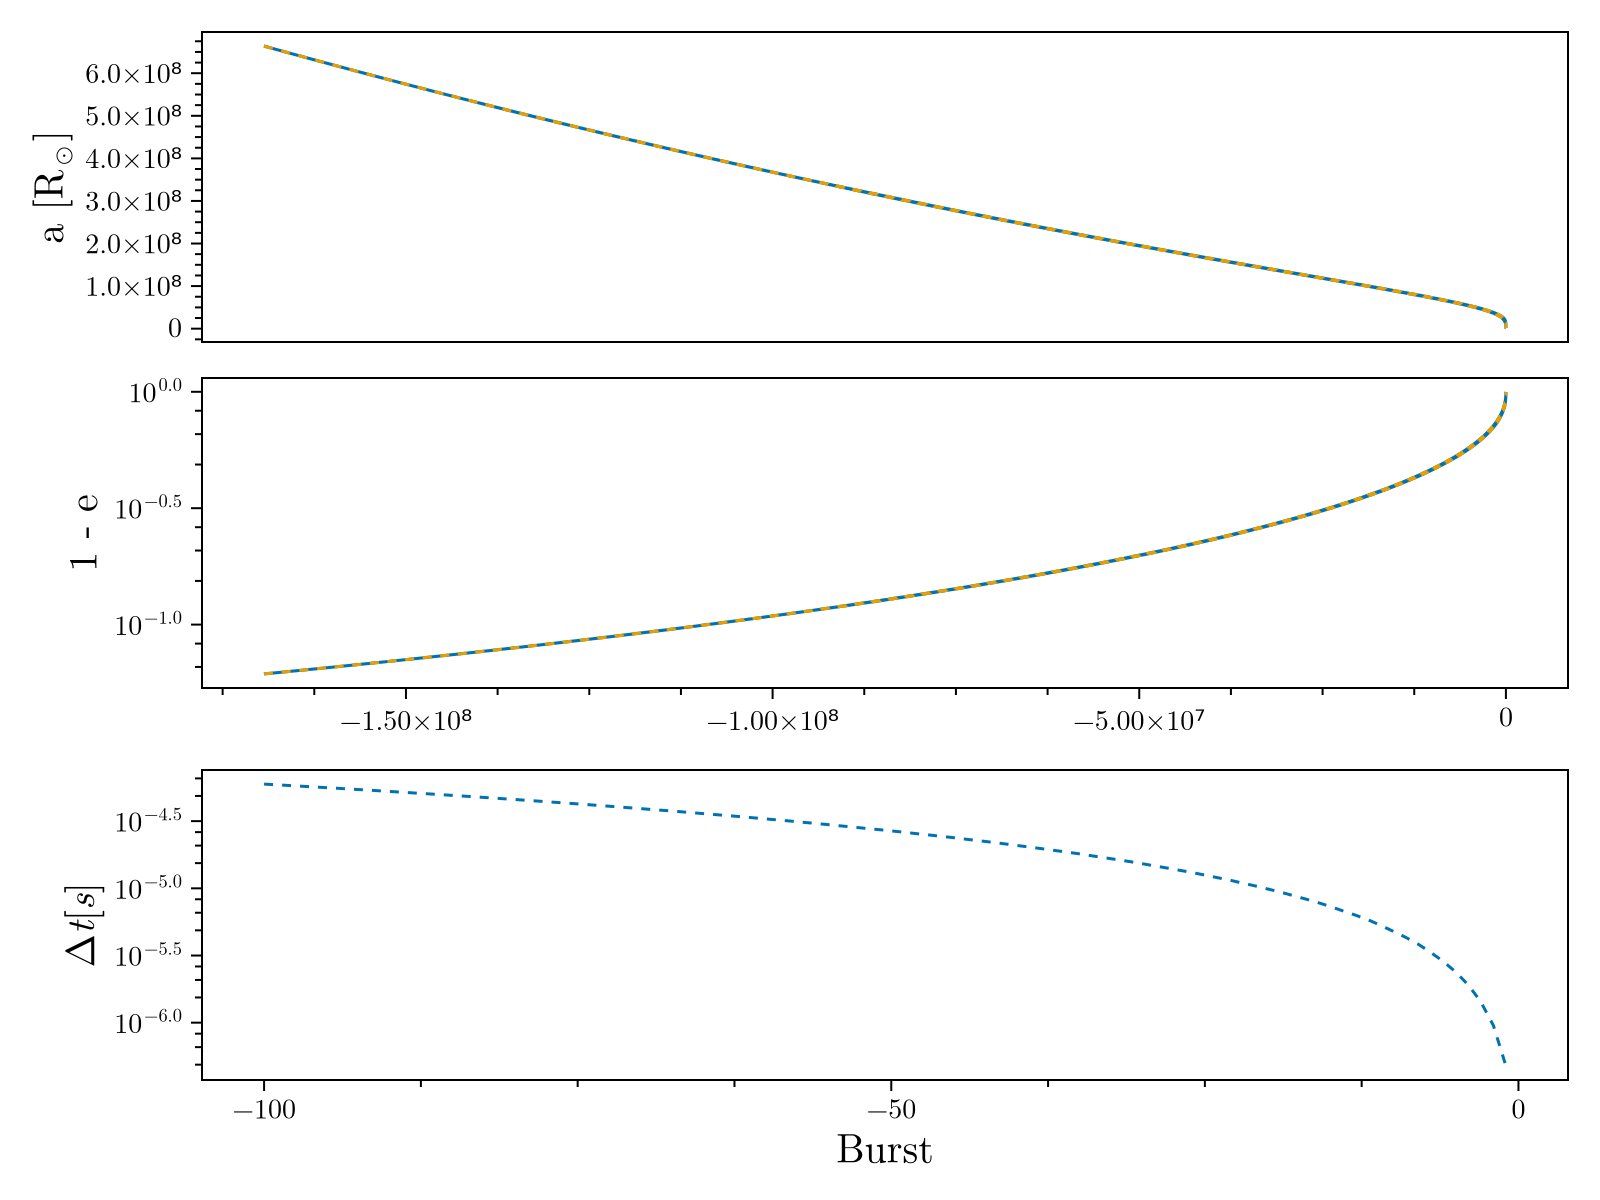

In [58]:
let models = get_bruenech_models()#get_kummer_models(e_min=0.1)
    
    IDs = collect(keys(models))
    

    params = models[IDs[1]]
    params[:iota3] = π/2
    # params[:W3] = π/4
    m_up, m_p = get_models(;params...)

    # println(EBT.peak_f_GW(m, 1))
    # t_decay_s = decay_time_s(params[:a0], params[:e0], params[:m1], params[:m2])
    # period_s = orbital_period_s(params[:a0], params[:m1], params[:m2])
    # T = t_decay_s/period_s
    # println(N)
    # println(EBT.peak_f_GW(m, N))

    # return EBT.get_R(m), EBT.get_Rmin(m, m.η₃/m.η)
    # return EBT.get_Rmin(m, m.η₃/m.η)/(m.p₃/(1 - m.e₃))
    # println(EBT.peak_f_GW(m, 1))
    evolve!(m_p, 1_000_000, f_GW_max=10, e_min=0.0001, verbose=true, Rmin_threshold=Inf, do_outer_orbit=true)
    evolve!(m_up, 1_000_000, f_GW_max=10, e_min=0.0001, verbose=true, Rmin_threshold=Inf)
    
    N = length(m_up.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_dt = Axis(fig[3, 1], ylabel=L"Δt [s]", xlabel="Burst", yscale=log10)

    hidexdecorations!(ax)
    # hidexdecorations!(ax_e)
    # linkxaxes!(ax, ax_e, ax_i)

    t_up = let m = m_up
        t = to_seconds(m, m.t)
        t = t .- t[end]
        a = to_meters(m, m.p ./ (1 .- m.e .^ 2))
        e = m.e

        lines!(ax, t, a)
        lines!(ax_e, t, 1 .- e)
        t
    end

    t_p = let m = m_p
        t = to_seconds(m, m.t)
        t = t .- t[end]
        a = to_meters(m, m.p ./ (1 .- m.e .^ 2))
        e = m.e
        i = m.ι

        lines!(ax, t, a, linestyle=:dash)
        lines!(ax_e, t, 1 .- e, linestyle=:dash)
        t
    end

    n = 100
    lines!(ax_dt, -100:-1, abs.(t_up[end-n:end-1] .- t_p[end-n:end-1]), linestyle=:dash)

    fig
end

In [142]:
function get_header_arrays(model, N)
    e_array = EBT.get_e_array(model, N)
    a_array = EBT.get_a_array(model, N)
    t_array = EBT.get_t_array(model, N)
    w_array = EBT.get_w_array(model, N)
    V3_array = EBT.get_V3_array(model, N)

    W_array = EBT.get_W_array(model, N)
    i_array = EBT.get_i_array(model, N)

    return e_array, a_array, t_array, w_array, V3_array, W_array, i_array
end


function evolve_and_save_models(filename, model_data; outfile_appendix="", e_min=0.7, 
                                additional_params=Dict(), 
                                perturbed_options=Dict(), 
                                unperturbed_options=Dict())

    output_dir = replace(joinpath(DATADIR, "evolution", filename), ".csv" => outfile_appendix)
    !isdir(output_dir) && mkdir(output_dir)
    
    lck = ReentrantLock()
    models = model_data(filename, e_min=e_min)

    IDs = collect(keys(models))
    # return IDs
    header = ["time_s", "a_m", "e", "w", "iota", "W", "V3", "fGW"]
    n_bursts_up = pop!(unperturbed_options, :n_bursts, 1_000_000)
    n_bursts_pert = pop!(perturbed_options, :n_bursts, 1_000_000)
    Threads.@threads for ID in IDs
        params = models[ID]
        params[:V3] = π
        params = merge(params, additional_params)
        t_decay_s = decay_time_s(params[:a0], params[:e0], params[:m1], params[:m2])
        period_s = orbital_period_s(params[:a0], params[:m1], params[:m2])
        # if t_decay_s/period_s > 1e6
        #     continue
        # end

        m, m_pert = get_models(;params...)
        
        outfile = joinpath(output_dir, "$(ID).jld2")
        # println(outfile)
        let model = m
            evolve!(model, n_bursts_up, f_GW_max=100, e_min=0.001; unperturbed_options...)
            N = length(model.t)
            success = EBT.peak_f_GW(model, N) >= 9

            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            # CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)
            JLD2.save(outfile, "time_s", t, "a_m", a, "e", e, "w", w, "iota", i, "W", W, "V3", V3, "fGW", fGWs, "success", success)
        end

        let model = m_pert
            evolve!(model, n_bursts_pert, f_GW_max=100, e_min=0.001; perturbed_options...)
            N = length(model.t)
            success = EBT.peak_f_GW(model, N) >= 9

            outfile = replace(outfile, ".jld2" => "_pert.jld2")
            # println(outfile)

            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            # CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)
            JLD2.save(outfile, "time_s", t, "a_m", a, "e", e, "w", w, "iota", i, "W", W, "V3", V3, "fGW", fGWs, "success", success)

        end
    end
end

evolve_and_save_models (generic function with 1 method)

In [141]:
evolve_and_save_models.(("simple_high_density_Z0005.csv",), get_kummer_models)

/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/1891.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/9026.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/7329.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/3885.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/4445.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/3885_pert.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/1891_pert.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_density_Z0005/4445_pert.jld2
/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data/evolution/simple_high_d

(nothing,)

In [143]:
let 
    data_models = ("simple_high_density_Z0005.csv", "basic_high_density_Z0005.csv", "GW_advanced_low_density_Z0005.csv", "GW_advanced_high_density_Z0005.csv")
    for data_model in data_models
        perturbed_options = Dict(:n_bursts => 2_000_000, :save_every => 1, :Rmin_threshold => Inf)
        unperturbed_options = Dict(:n_bursts => 100_000_000, :save_every => 100)
        evolve_and_save_models(data_model, get_kummer_models, 
                                perturbed_options=perturbed_options, 
                                unperturbed_options=unperturbed_options)

        # additional_params = Dict(:iota3 => π/2)
        # evolve_and_save_models(data_model, get_kummer_models, outfile_appendix="_inclined",
        #                         additional_params = additional_params,
        #                         perturbed_options=perturbed_options, 
        #                         unperturbed_options=unperturbed_options)
    end
end

In [17]:
let data_model = "triple-induced-mergers.csv"
    evolution_options = Dict(:n_bursts => 10_000_000, :save_every => 5, :Rmin_threshold => Inf)
    # evolve_and_save_models(data_model, get_bruenech_models, 
    #                         additional_params = additional_params,
    #                         perturbed_options=evolution_options, 
    #                         unperturbed_options=evolution_options)

    additional_params = Dict(:iota3 => π/2)
    evolve_and_save_models(data_model, get_bruenech_models, outfile_appendix="_inclined",
                            additional_params = additional_params,
                            perturbed_options=evolution_options, 
                            unperturbed_options=evolution_options)
end

In [158]:
const LISA_min, LISA_max = (1e-3, 0.1)
const DECIGO_min, DECIGO_max = (0.1, 1)
const ET_min, ET_max = (1, 10)
const LIGO_min, LIGO_max = (10, 100)

function plot_evolution(filepath; loge=true, loga=false)

    cs = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]", yscale = loga ? log10 : identity)
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=loge ? log10 : identity)
    ax_fGW = Axis(fig[3, 1], ylabel="f [Hz]", yscale=log10)
    ax_i = Axis(fig[4, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel=L"$t - t_\text{end}$ [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    hidexdecorations!(ax_fGW)
    linkxaxes!(ax, ax_e, ax_i, ax_fGW)

    hspan!(ax_fGW, LISA_min, LISA_max, color=(cs[end], 0.2))
    hspan!(ax_fGW, DECIGO_min, DECIGO_max, color=(cs[end-1], 0.2))
    hspan!(ax_fGW, ET_min, ET_max, color=(cs[end-2], 0.2))
    hspan!(ax_fGW, LIGO_min, LIGO_max, color=(cs[end-3], 0.2))

    t, a, e, f = let
        jldopen(filepath) do fl
            t = fl["time_s"]
            a = fl["a_m"] ./ EBT.Rsun_to_m
            e = fl["e"]
            f = fl["fGW"]
            println(f[end])
            t, a, e, f
        end
    end

    t_pert, a_pert, e_pert, f_pert, i = let
        jldopen(replace(filepath, ".jld2" => "_pert.jld2")) do fl
            t_p = fl["time_s"]
            a_p = fl["a_m"] ./ EBT.Rsun_to_m
            e_p = fl["e"]
            f_p = fl["fGW"]
            i_p = fl["iota"]
            println(f_p[end])
            i_lims = extrema(i_p)
            ylims!(ax_i, 0.9i_lims[1], 1.1i_lims[2])
            t_p, a_p, e_p, f_p, i_p
        end
    end

    Tmax, Tmax_pert = t[end], t_pert[end]
    # t = t .- Tmax
    # t_pert = t_pert .-= Tmax_pert

    Δt = t_pert[end] - t[end]
    t = t .+ Δt

    lines!(ax, t, a, color=cs[1])
    lines!(ax_e, t, loge ? 1 .- e : e, color=cs[1])
    lines!(ax_fGW, t, f, color=cs[1])

    lines!(ax, t_pert, a_pert, color=cs[2], linestyle=:dash)
    lines!(ax_e, t_pert, loge ? 1 .- e_pert : e_pert, color=cs[2], linestyle=:dash)
    lines!(ax_fGW, t_pert, f_pert, color=cs[2], linestyle=:dash)
    lines!(ax_i, t_pert, i, color=cs[3])

    axislegend(ax, [LineElement(color=cs[1]), LineElement(color=cs[2], linestyle=:dash)], 
                   ["Unperturbed", "Perturbed"], position=:lb, labelsize=20)
    fig
end

function plot_evolution_vs_f(filepath; loge=true, loga=false, t_norm=true)

    cs = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]", yscale = loga ? log10 : identity, xscale=log10)
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=loge ? log10 : identity, xscale=log10)


    vspan!(ax, LISA_min, LISA_max, color=(cs[end], 0.2))
    vspan!(ax, DECIGO_min, DECIGO_max, color=(cs[end-1], 0.2))
    vspan!(ax, ET_min, ET_max, color=(cs[end-2], 0.2))
    vspan!(ax, LIGO_min, LIGO_max, color=(cs[end-3], 0.2))

    vspan!(ax_e, LISA_min, LISA_max, color=(cs[end], 0.2))
    vspan!(ax_e, DECIGO_min, DECIGO_max, color=(cs[end-1], 0.2))
    vspan!(ax_e, ET_min, ET_max, color=(cs[end-2], 0.2))
    vspan!(ax_e, LIGO_min, LIGO_max, color=(cs[end-3], 0.2))

    hidexdecorations!(ax)
    linkxaxes!(ax, ax_e)

    jldopen(filepath) do fl
        t = fl["time_s"]
        a = fl["a_m"] ./ EBT.Rsun_to_m
        e = fl["e"]
        f = fl["fGW"]
        # i = fl.iota
        # println(f[end])
        t = t_norm ? t ./ t[end] : t

        lines!(ax, f, a, color=cs[1])
        lines!(ax_e, f, loge ? 1 .- e : e, color=cs[1])
        # lines!(ax_fGW, t, f, color=cs[1])
        # lines!(ax_i, t, i)

    end

    jldopen(replace(filepath, ".jld2" => "_pert.jld2")) do fl
        t = fl["time_s"]
        a = fl["a_m"] ./ EBT.Rsun_to_m
        e = fl["e"]
        f = fl["fGW"]
        i = fl["iota"]
        # println(f[end])
        i_lims = extrema(i)
        # ylims!(ax_i, 0.9i_lims[1], 1.1i_lims[2])

        t = t_norm ? t ./ t[end] : t

        lines!(ax, f, a, color=cs[3], linestyle=:dash)
        lines!(ax_e, f, loge ? 1 .- e : e, color=cs[3], linestyle=:dash)
        # lines!(ax_i, t, i, color=cs[3])
        # lines!(ax_fGW, t, f, color=cs[3], linestyle=:dash)

    end

    LE = LineElement
    PE = PolyElement
    Legend(fig[0,1], [LE(color=cs[1]), LE(color=cs[3], linestyle=:dash), 
                      PE(color=(cs[end], 0.2)), PE(color=(cs[end-1], 0.2)), PE(color=(cs[end-2], 0.2)), PE(color=(cs[end-3], 0.2))], 
                   ["Unperturbed", "Perturbed", "LISA", "DECIGO", "ET", "LIGO"], labelsize=20,
                   orientation=:horizontal)
    fig
end

plot_evolution_vs_f (generic function with 1 method)

In [160]:
let ms = readdir("../data/evolution/simple_high_density_Z0005", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    # println(ms[1])
    println(ms[1])
    # plot_evolution(ms[1], loge=true, loga=true)
    # plot_evolution_vs_f(ms[3], loge=true, loga=true, t_norm=false) 
#     s = 0
#     for m in ms
#         jldopen(m) do fl
#             if fl["success"]
#                 s += 1
#                 # e = fl["e"]
#                 # if length(e) < 2_000_002
#                 #     println(split(m, "/")[end], " ", e[end])
#                 # end
#             end
#         end
#     end
# s/length(ms)
end

../data/evolution/simple_high_density_Z0005/1891.jld2


In [12]:
let ms = readdir("../data/evolution/triple-induced-mergers", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    # plot_evolution_vs_f(ms[2], loge=true, loga=true) 
    # plot_evolution(ms[3], loge=true, loga=true)
    s = 0
    for m in ms
        jldopen(m) do fl
            if !fl["success"]
                s += 1
                # e = fl["e"]
                # if length(e) < 2_000_002
                #     println(split(m, "/")[end], " ", e[end])
                # end
            end
        end
    end
s
end

10

## Plot $\Delta t$

In [ ]:
function plot_dt(filepath, n_bursts; yscale=identity, filter_0s=false)

    cs = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="Burst number", ylabel=L"\Delta t [s]", yscale=yscale)

    t, success = let
        jldopen(filepath) do fl
            t = fl["time_s"]
            # f = fl["fGW"]

            t[end:-1:end-n_bursts+1], fl["success"]
        end
    end

    t_pert, success_pert = let
        jldopen(replace(filepath, ".jld2" => "_pert.jld2")) do fl
            t_p = fl["time_s"]
            # f_p = fl["fGW"]
            t_p[end:-1:end-n_bursts+1], fl["success"]
        end
    end

    if !success
        @info "Unperturbed unsuccessfull"
        return fig
    end

    if !success_pert
        @info "Perturbed unsuccessfull"
        return fig
    end

    # Tmax, Tmax_pert = t[end], t_pert[end]
    Δt = t_pert[end] - t[end]
    t = t .+ Δt
    
    dt = abs.(t .- t_pert)
    if filter_0s
        filter!(x -> !iszero(x), dt)
    end

    scatter!(ax, -length(dt)+1:0, dt, color=cs[1])
    
    fig
end

function plot_dt_vs_f(filepath, n_bursts; yscale=identity, filter_0s=false)

    cs = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="f [Hz]", ylabel=L"\Delta t [s]", yscale=yscale)

    t, f, success = let
        jldopen(filepath) do fl
            t = fl["time_s"]
            f = fl["fGW"]
            t[end-n_bursts+1:end], f[end-n_bursts+1:end], fl["success"]
        end
    end

    t_pert, f_pert, success_pert = let
        jldopen(replace(filepath, ".jld2" => "_pert.jld2")) do fl
            t_p = fl["time_s"]
            f_p = fl["fGW"]
            t_p[end-n_bursts+1:end], f_p[end-n_bursts+1:end], fl["success"]
        end
    end

    if !success
        @info "Unperturbed unsuccessful"
        return fig
    end

    if !success_pert
        @info "Perturbed unsuccessful"
        return fig
    end

    Δt = t_pert[end] - t[end]
    t = t .+ Δt

    dt = abs.(t .- t_pert)
    if filter_0s
        ids_nonzero = findall(x -> !iszero(x), dt)
        dt = dt[ids_nonzero]
        f = f[ids_nonzero]
    end


    scatter!(ax, f, dt, color=cs[1])
    
    fig
end


plot_dt_vs_f (generic function with 1 method)

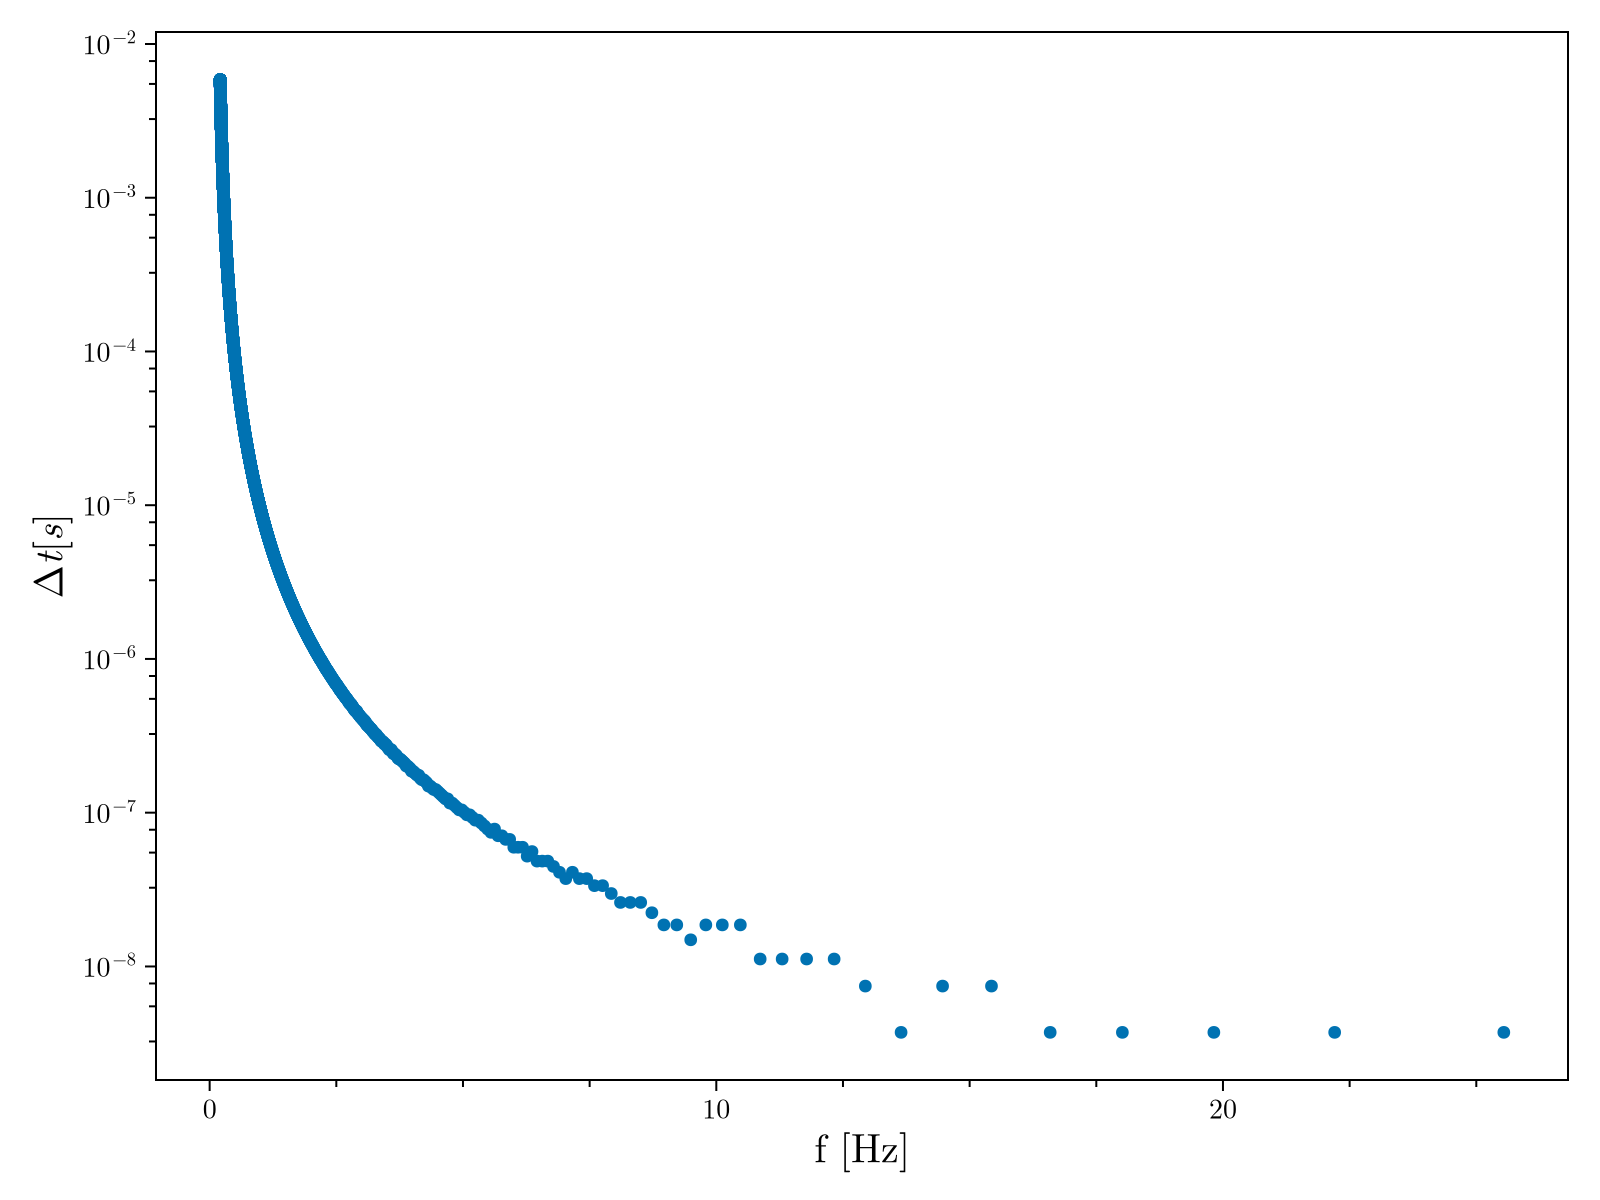

In [85]:
let ms = readdir("../data/evolution/triple-induced-mergers_inclined", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    plot_dt_vs_f(ms[1], 30000, yscale=log10, filter_0s=true)
end

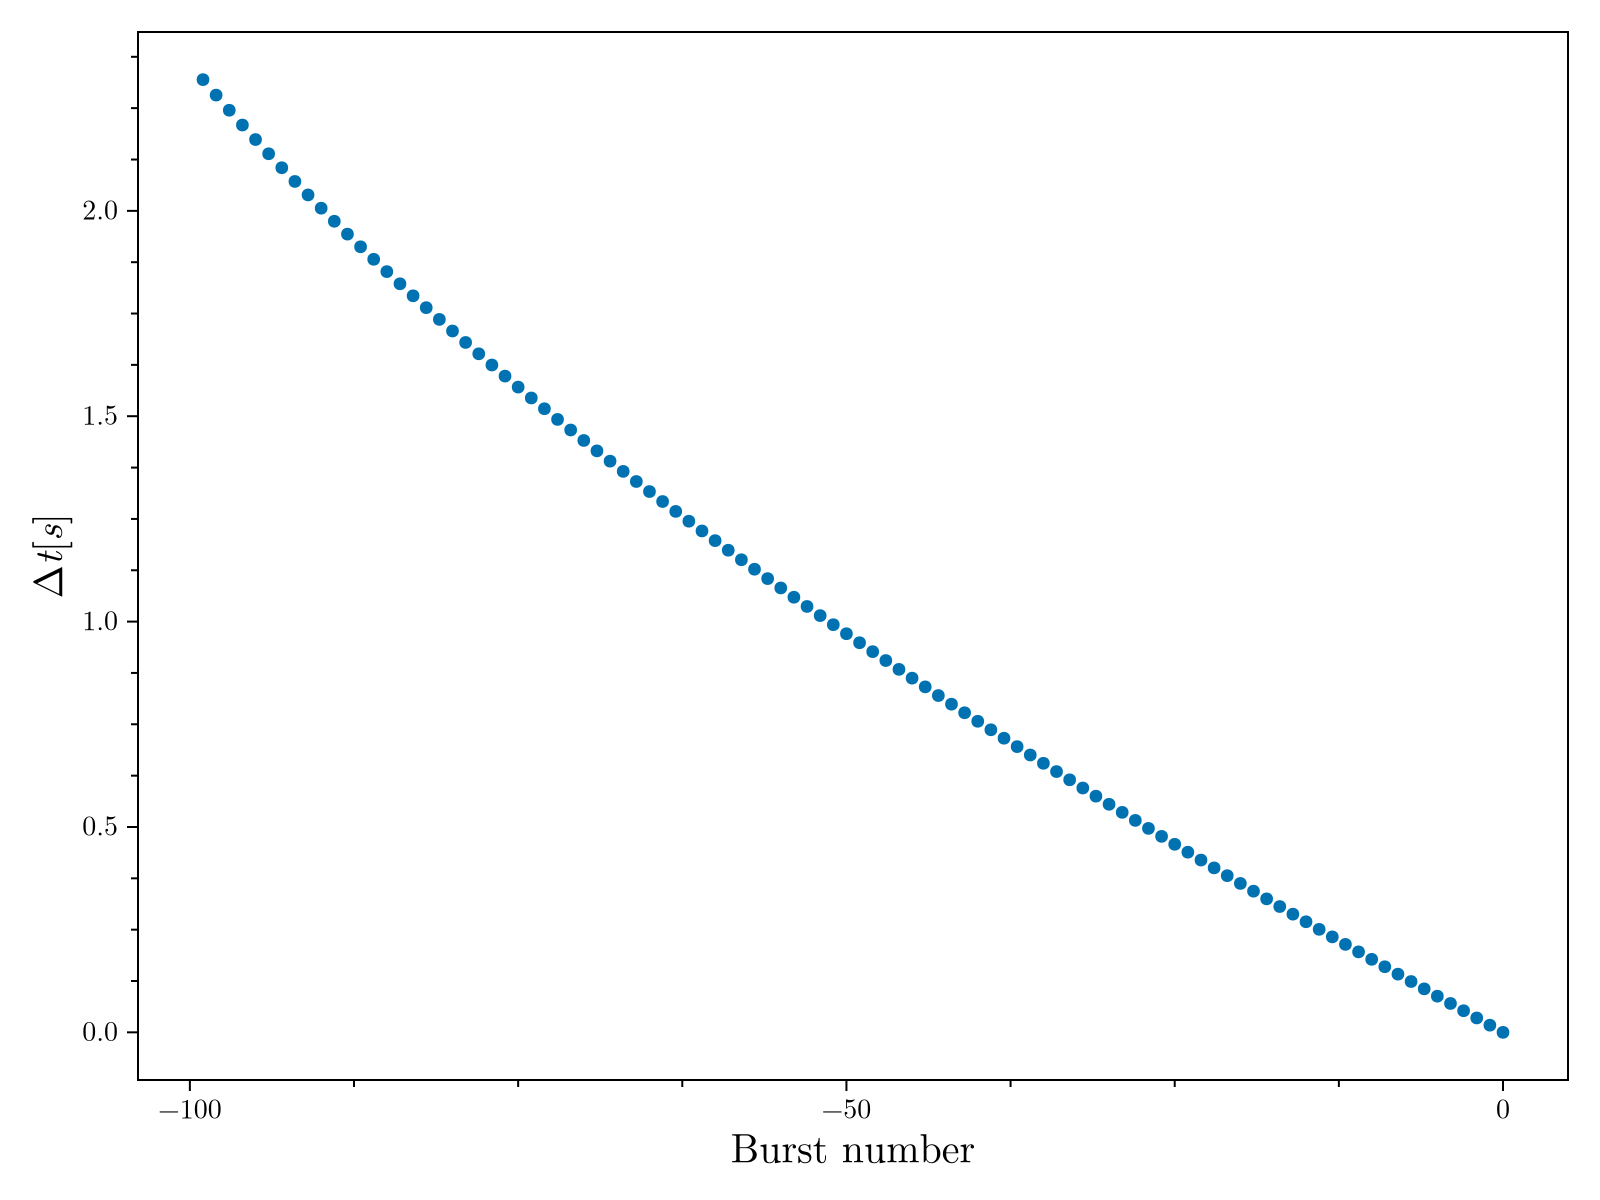

In [ ]:
let ms = readdir("../data/evolution/GW_advanced_high_density_Z0005", join=true)#ms = readdir("../data/evolution/triple-induced-mergers", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    plot_dt(ms[1], 100, yscale=identity)
end

# $\Delta t$ at different frequencies

In [1]:
let
    cs = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="Peak frequency [Hz]", 
                         ylabel=L"\Delta t_\text{max} [s]",
                         xscale=log10, yscale=log10)
    
    vspan!(ax, LISA_min, LISA_max, color=(cs[end], 0.2))
    vspan!(ax, DECIGO_min, DECIGO_max, color=(cs[end-1], 0.2))
    vspan!(ax, ET_min, ET_max, color=(cs[end-2], 0.2))
    vspan!(ax, LIGO_min, LIGO_max, color=(cs[end-3], 0.2))

    # line up end times, go back in bursts
    search_func(ex, y) = findlast(x -> x <= ex, y)#findfirst(x -> x >= ex, y)

    data_models = ("GW_advanced_high_density_Z0005", "GW_advanced_low_density_Z0005", "triple-induced-mergers_inclined") 
    for data_dir in data_models
        marker = contains(data_dir, "triple-induced") ? :x : :circle
        files = readdir(joinpath(DATADIR, "evolution", data_dir), join=true)
        filter!(x -> !contains(x, "_pert"), files)
        for file in files
            file_pert = replace(file, ".jld2" => "_pert.jld2")

            t, fGW, success = JLD2.load(file, "time_s", "fGW", "success")
            t_pert, fGW_pert, success_pert = JLD2.load(file_pert, "time_s", "fGW", "success")

            Δt = t_pert[end] - t[end]
            t = t .+ Δt

            # if !success || !success_pert
            #     continue
            # end

            if (fGW[end] < 5) || (fGW_pert[end] < 5)
                continue
            end

            LISA_ids = findall(x -> LISA_min < x < LISA_max, fGW)
            DECIGO_ids = findall(x -> DECIGO_min < x < DECIGO_max, fGW)
            ET_ids = findall(x -> ET_min < x < ET_max, fGW)
            LIGO_ids = findall(x -> LIGO_min < x < LIGO_max, fGW)

            LISA_ids_pert = findall(x -> LISA_min < x < LISA_max, fGW_pert)
            DECIGO_ids_pert = findall(x -> DECIGO_min < x < DECIGO_max, fGW_pert)
            ET_ids_pert = findall(x -> ET_min < x < ET_max, fGW_pert)
            LIGO_ids_pert = findall(x -> LIGO_min < x < LIGO_max, fGW_pert)

            if !iszero(LISA_ids) && !iszero(LISA_ids_pert)
                examples = (1e-3, 1e-2, 1e-1)
                for ex in examples
                    idx_min = search_func(ex, fGW)#argmin(abs.(fGW .- ex))
                    idx_min_pert = search_func(ex, fGW_pert)#argmin(abs.(fGW_pert .- ex))
                    (isnothing(idx_min) || isnothing(idx_min_pert)) && continue

                    scatter!(ax, fGW[idx_min] + fGW[idx_min]*randn()/10, abs(t[idx_min] - t_pert[idx_min_pert]), color=cs[end], 
                                marker=marker, strokewidth=1, strokecolor=:black)
                end
            end

            if !iszero(DECIGO_ids) && !iszero(DECIGO_ids_pert)
                examples = (0.5,)
                for ex in examples
                    idx_min = search_func(ex, fGW)#argmin(abs.(fGW .- ex))
                    idx_min_pert = search_func(ex, fGW_pert)#argmin(abs.(fGW_pert .- ex))
                    (isnothing(idx_min) || isnothing(idx_min_pert)) && continue

                    scatter!(ax, fGW[idx_min] + fGW[idx_min]*randn()/10, abs(t[idx_min] - t_pert[idx_min_pert]), color=cs[end-1], marker=marker)
                end
            end
            
            if !iszero(ET_ids) && !iszero(ET_ids_pert)
                examples = (1, 5)
                for ex in examples
                    idx_min = search_func(ex, fGW)#argmin(abs.(fGW .- ex))
                    idx_min_pert = search_func(ex, fGW_pert)#argmin(abs.(fGW_pert .- ex))
                    (isnothing(idx_min) || isnothing(idx_min_pert)) && continue

                    scatter!(ax, fGW[idx_min] + fGW[idx_min]*randn()/10, abs(t[idx_min] - t_pert[idx_min_pert]), color=cs[end-2], marker=marker)
                end
            end

            if !iszero(LIGO_ids) && !iszero(LIGO_ids_pert)
                examples = (10, 15, 20)
                for ex in examples
                    idx_min = search_func(ex, fGW)#argmin(abs.(fGW .- ex))
                    idx_min_pert = search_func(ex, fGW_pert)#argmin(abs.(fGW_pert .- ex))
                    (isnothing(idx_min) || isnothing(idx_min_pert)) && continue
                    scatter!(ax, fGW[idx_min] + fGW[idx_min]*randn()/10, abs(t[idx_min] - t_pert[idx_min_pert]), color=cs[end-3], marker=marker)
                end
            end
        end
    end

    # hlines!(ax, 1e-3, color=:gray)
    # hlines!(ax, 1e-4, color=:gray)
    PE = PolyElement
    ME = MarkerElement
    lbl = contains(data_models[end], "inclined") ? "ZKL (inclined)" : "ZKL"
    Legend(fig[0,1], [PE(color=(cs[end], 0.4)), PE(color=(cs[end-1], 0.4)), 
                      PE(color=(cs[end-2], 0.4)), PE(color=(cs[end-3], 0.4)),
                      ME(color=:black, marker=:circle), ME(color=:black, marker=:x)], 
                     ["LISA", "DECIGO", "ET", "LIGO", "CHE", lbl], labelsize=20,
                   orientation=:horizontal)
    fig
end

LoadError: LoadError: UndefVarError: `@L_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /home/cwbruenech/projects/EccentricBurstTimings/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sdnNjb2RlLXJlbW90ZQ==.jl:5

## $e_\text{LIGO}$

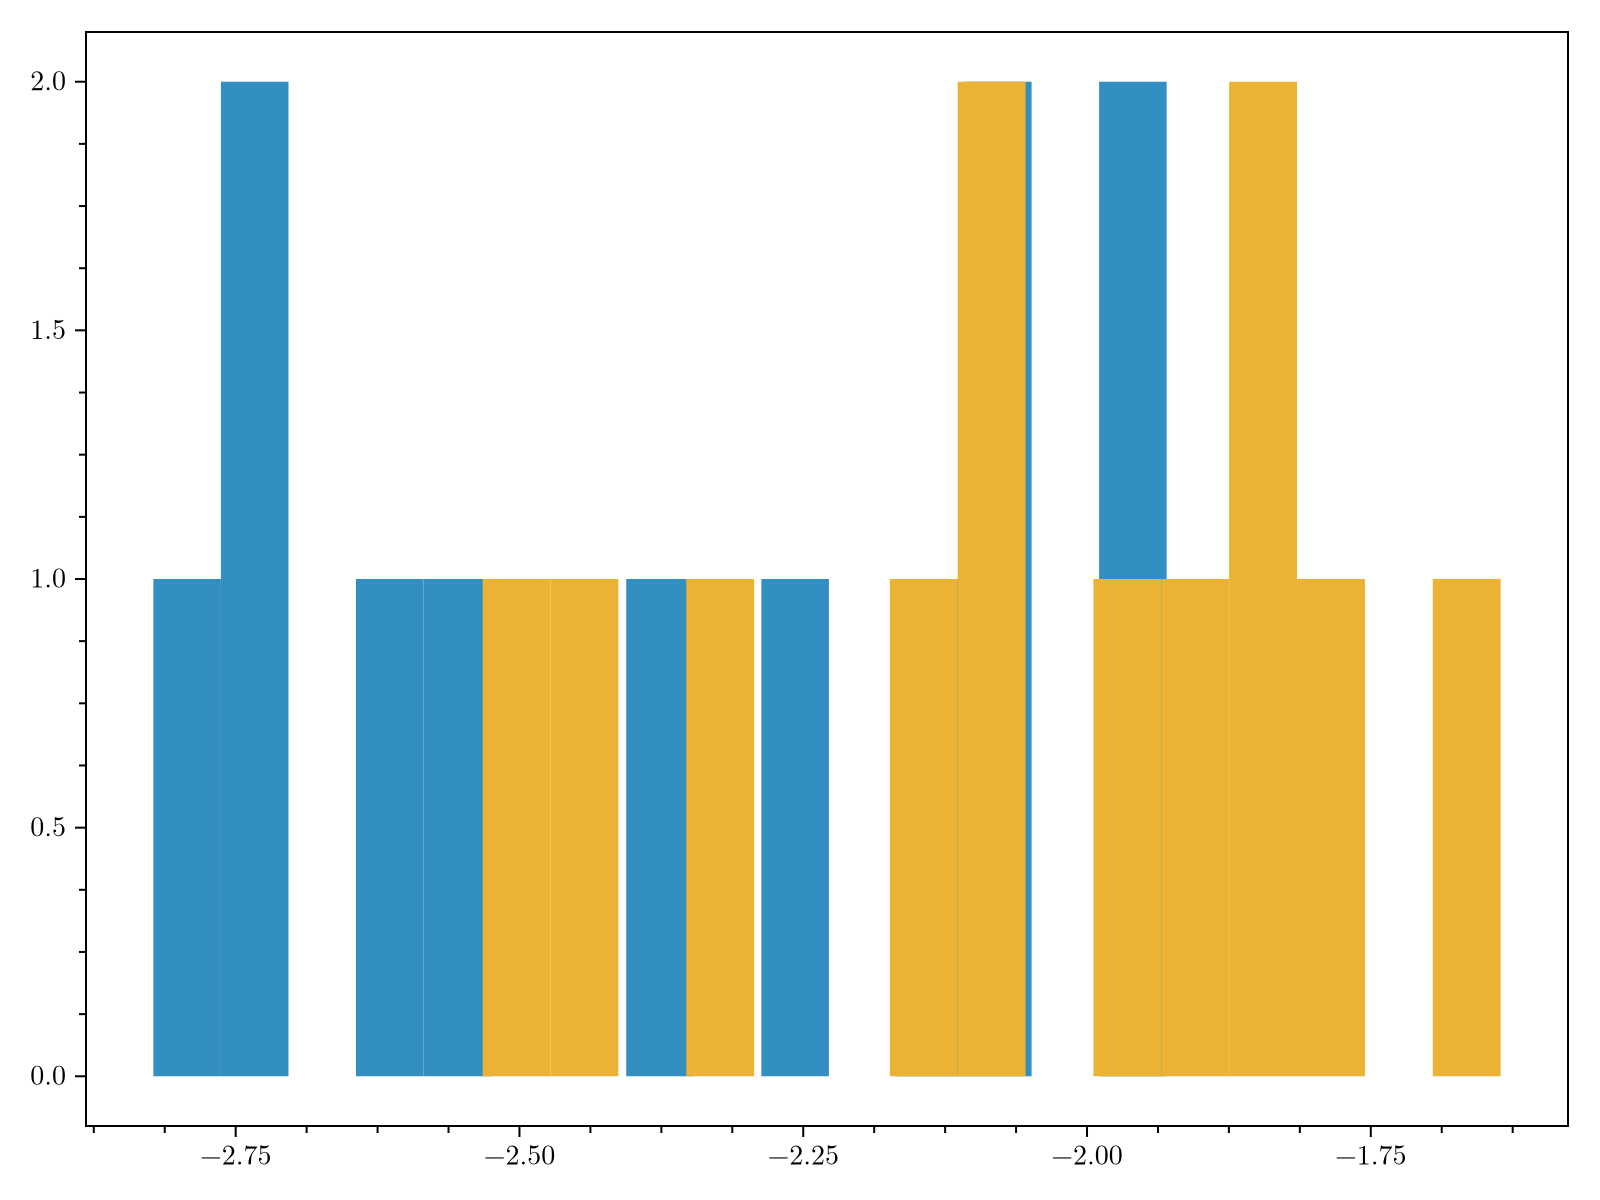

In [167]:
let 
    fig = Figure()
    ax = Axis(fig[1, 1])

    es_kummer, es_bruenech = Tuple{Float64, Float64}[], Tuple{Float64, Float64}[]
    for data_dir in ("GW_advanced_high_density_Z0005", "triple-induced-mergers")
        marker = contains(data_dir, "triple-induced") ? :x : :circle
        files = readdir(joinpath(DATADIR, "evolution", data_dir), join=true)
        filter!(x -> !contains(x, "_pert"), files)

        for file in files
            file_pert = replace(file, ".jld2" => "_pert.jld2")

            e, f = JLD2.load(file, "e", "fGW")
            e_pert, f_pert = JLD2.load(file_pert, "e", "fGW")

            ((f[end] < 10) || (f_pert[end] < 10)) && continue
            
            e10Hz = e[findfirst(x -> x >= 10, f)]
            e10Hz_pert = e_pert[findfirst(x -> x >= 10, f_pert)]
            if contains(data_dir, "triple-induced")
                push!(es_bruenech, (e10Hz, e10Hz_pert))
            else
                push!(es_kummer, (e10Hz, e10Hz_pert))
            end
        end
            # e_pert, f_pert = JLD2.load(file_pert, "e", "fGW")


    end
   
    # hist!(ax, es_kummer, normalization=:probability)
    # hist!(ax, es_bruenech, normalization=:probability)
    hist!(ax, getindex.(es_kummer, 1) .|> log10)
    hist!(ax, getindex.(es_kummer, 2) .|> log10)
    # scatter!(ax, getindex.(es_bruenech, 1) .|> log10, getindex.(es_bruenech, 2) .|> log10)
    # scatter!(ax, es_bruenech)
    fig
end